### Download and Load Data



In [2]:
!kaggle datasets download -d briscdataset/brisc2025

Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
100% 250M/250M [00:04<00:00, 54.9MB/s]



In [3]:
# Corrected: Unzip the downloaded zip file
!unzip brisc2025.zip

# List files in the current directory to see the extracted data
!ls

Streaming output truncated to the last 5000 lines.
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03935_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03936_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03937_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03938_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03939_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03940_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03941_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03942_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03943_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03944_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_tas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('brisc2025/manifest.csv')

In [6]:
df.head()

,relative_path,filename,task,split,index,tumor_code,tumor_label,plane_code,plane_label,sequence,is_mask,linked_image,width,height,file_size_bytes,sha256
0,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00001_gl_ax_t1.jpg,classification,test,1,gl,glioma,ax,axial,T1,False,NaN,512,512,25826,b513a83f68e486f45159b004d356782e78284014532151...
1,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00002_gl_ax_t1.jpg,classification,test,2,gl,glioma,ax,axial,T1,False,NaN,512,512,20982,5b4e4a0f482cb68955c340205d475f25c3a30718bd3b48...
2,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00003_gl_ax_t1.jpg,classification,test,3,gl,glioma,ax,axial,T1,False,NaN,512,512,13285,6fd1918b39e7a7f92fa5652d7802583f3251fed50a23ec...
3,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00004_gl_ax_t1.jpg,classification,test,4,gl,glioma,ax,axial,T1,False,NaN,512,512,26137,216b65a45d7effb4ebce1c9893f97d12449c9da777f818...
4,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00005_gl_ax_t1.jpg,classification,test,5,gl,glioma,ax,axial,T1,False,NaN,512,512,21709,c35734545021ab5a4f55fb87e08732e26fb16abe887927...


In [7]:
df.shape

(15586, 16)

In [8]:
classification_data=df[df['task']=='classification']

In [9]:
classification_data

,relative_path,filename,task,split,index,tumor_code,tumor_label,plane_code,plane_label,sequence,is_mask,linked_image,width,height,file_size_bytes,sha256
0,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00001_gl_ax_t1.jpg,classification,test,1,gl,glioma,ax,axial,T1,False,NaN,512,512,25826,b513a83f68e486f45159b004d356782e78284014532151...
1,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00002_gl_ax_t1.jpg,classification,test,2,gl,glioma,ax,axial,T1,False,NaN,512,512,20982,5b4e4a0f482cb68955c340205d475f25c3a30718bd3b48...
2,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00003_gl_ax_t1.jpg,classification,test,3,gl,glioma,ax,axial,T1,False,NaN,512,512,13285,6fd1918b39e7a7f92fa5652d7802583f3251fed50a23ec...
3,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00004_gl_ax_t1.jpg,classification,test,4,gl,glioma,ax,axial,T1,False,NaN,512,512,26137,216b65a45d7effb4ebce1c9893f97d12449c9da777f818...
4,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00005_gl_ax_t1.jpg,classification,test,5,gl,glioma,ax,axial,T1,False,NaN,512,512,21709,c35734545021ab5a4f55fb87e08732e26fb16abe887927...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,classification_task\train\pituitary\brisc2025_...,brisc2025_train_04996_pi_sa_t1.jpg,classification,train,4996,pi,pituitary,sa,sagittal,T1,False,NaN,512,512,26585,1b8e1c3d49cc36b62101afb9ad5ec9a94e2871dfcbee19...
5996,classification_task\train\pituitary\brisc2025_...,brisc2025_train_04997_pi_sa_t1.jpg,classification,train,4997,pi,pituitary,sa,sagittal,T1,False,NaN,512,512,27181,836eabb3d1b4260dd3ac8614fc14fce05548fa7aa22b46...
5997,classification_task\train\pituitary\brisc2025_...,brisc2025_train_04998_pi_sa_t1.jpg,classification,train,4998,pi,pituitary,sa,sagittal,T1,False,NaN,512,512,24488,eacaef73a62d91a63bbe02be5738c249f52e3ac1067381...
5998,classification_task\train\pituitary\brisc2025_...,brisc2025_train_04999_pi_sa_t1.jpg,classification,train,4999,pi,pituitary,sa,sagittal,T1,False,NaN,512,512,24289,d1be0d6195cd814e52da334cdd4eab782c2c854f7665a1...


# **Brain Tumor Classification**

In [10]:
class_train = classification_data[classification_data['split']=='train'].copy()
class_test = classification_data[classification_data['split']=='test'].copy()

In [11]:
print(class_train['tumor_label'].value_counts())

tumor_label
pituitary     1457
meningioma    1329
glioma        1147
no_tumor      1067
Name: count, dtype: int64


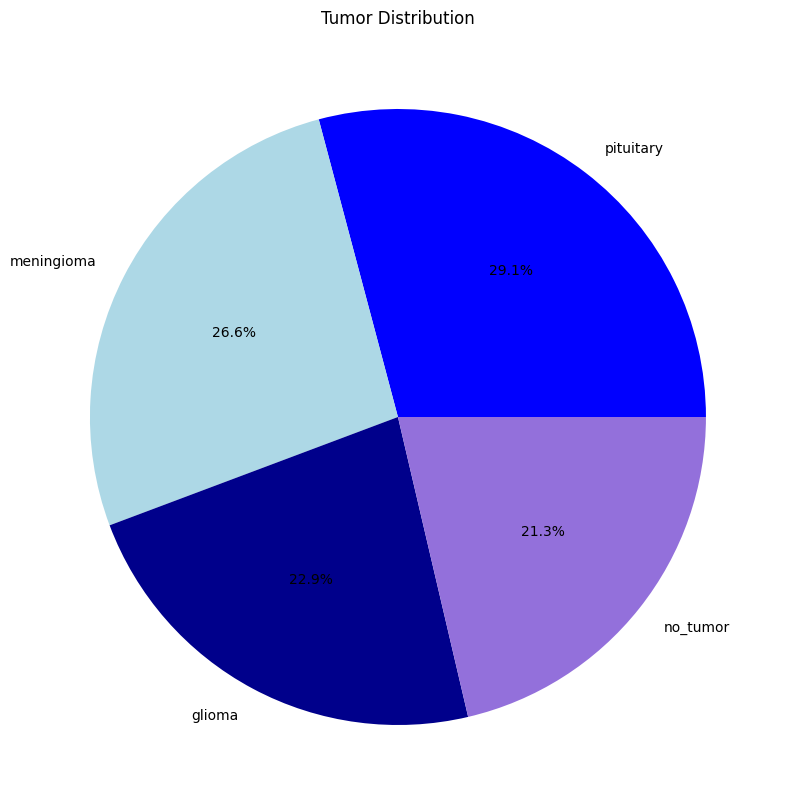

In [12]:
plt.figure(figsize=(10,10))
plt.pie(class_train['tumor_label'].value_counts(),labels=class_train['tumor_label'].value_counts().index, autopct='%1.1f%%',colors=['blue','lightblue','darkblue','mediumpurple'])
plt.title('Tumor Distribution')
plt.show()

In [13]:
BATCH_SIZE=32
HEIGHT, WIDTH = 512,512

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [15]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
   rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
     validation_split = 0.1
)

val_datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split = 0.1
)

In [16]:
class_train['relative_path'] = class_train['relative_path'].apply(lambda x: x.replace('\\', '/'))

train_generator=train_datagen.flow_from_dataframe(
    dataframe=class_train,
    directory='brisc2025',
    x_col='relative_path',
    y_col='tumor_label',
    target_size=(HEIGHT,WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    color_mode='rgb',
    shuffle=True,
    seed=0
)

Found 4500 validated image filenames belonging to 4 classes.


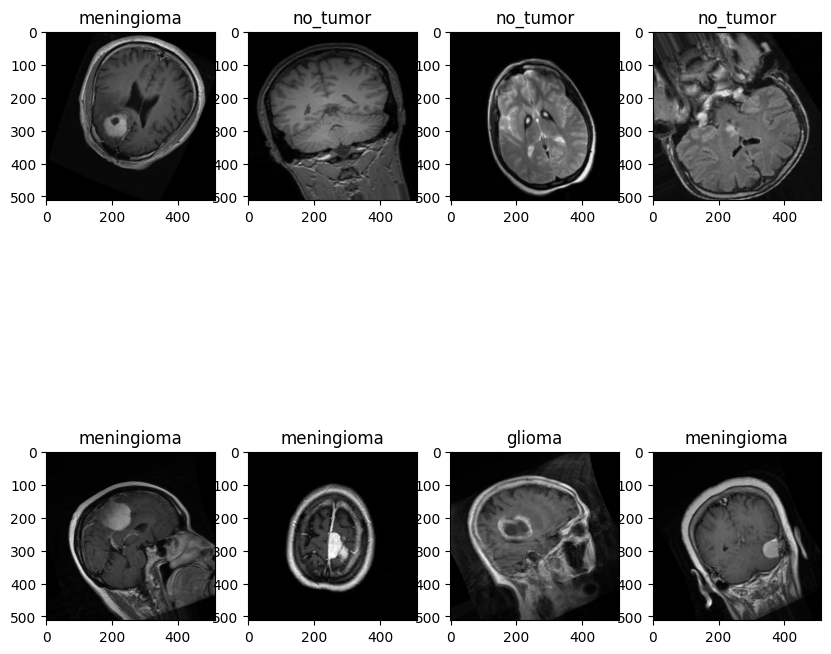

In [17]:
classes=list(train_generator.class_indices.keys())
plt.figure(figsize=(10,10))
for x,y in train_generator:
 for i in range(0,8):
  plt.subplot(2,4,i+1)
  plt.imshow(x[i])
  plt.title(classes[np.where(y[i]==1)[0][0]])

 plt.show()
 break

In [27]:
validation_generator=val_datagen.flow_from_dataframe(
    dataframe=class_train,
    directory='brisc2025',
    x_col='relative_path',
    y_col='tumor_label',
    target_size=(HEIGHT,WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb',
    shuffle=False,
    seed=0)

Found 500 validated image filenames belonging to 4 classes.


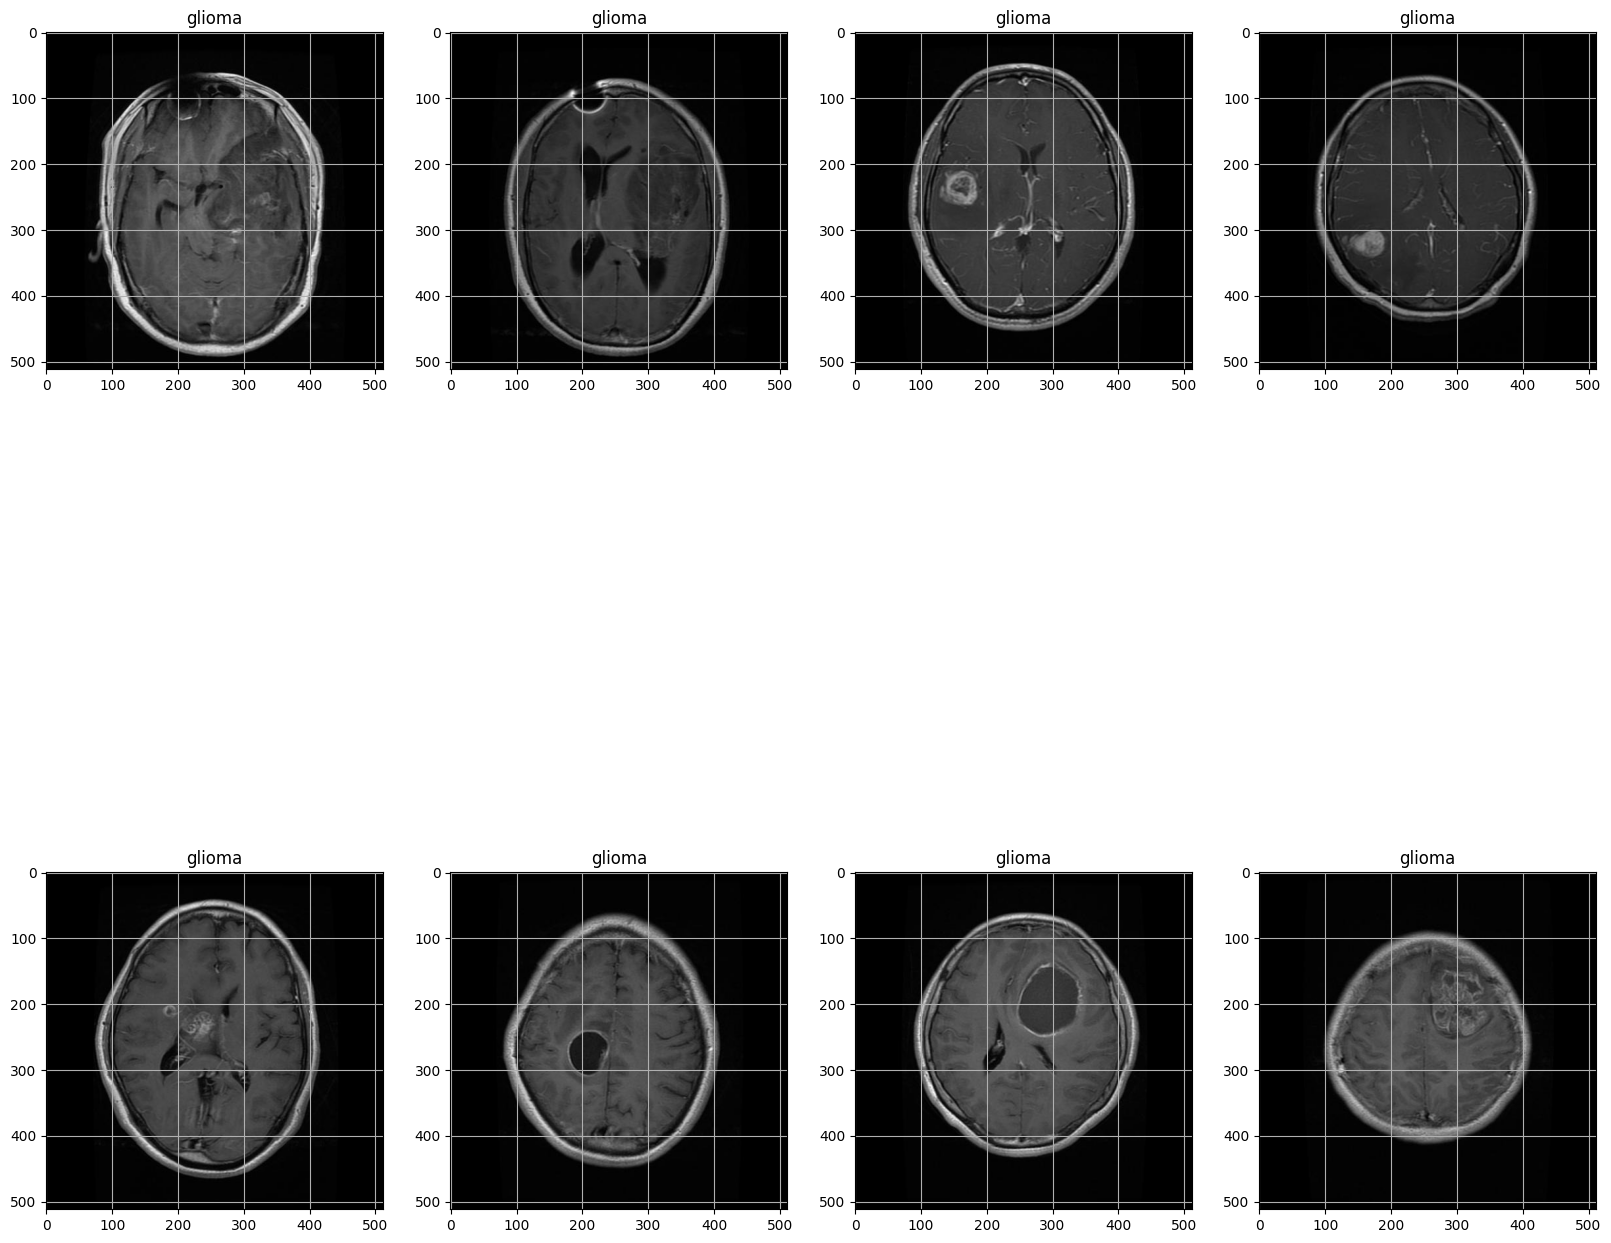

In [28]:
classes=list(validation_generator.class_indices.keys())
plt.figure(figsize=(20,20))
for x, y in validation_generator:
    for i in range(0,8):
        plt.subplot(2,4,i+1)
        plt.imshow(x[i])
        plt.title(classes[np.where(y[i]==1)[0][0]])
        plt.grid(None)

    plt.show()
    break

# **Model**

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,GlobalAveragePooling2D,BatchNormalization,  Dropout

In [30]:
model=Sequential([

    Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu',input_shape=(HEIGHT, WIDTH, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),


    Conv2D(64, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),


    Conv2D(128, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),


    Conv2D(256, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),


    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax')
])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 512, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 512, 512, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 652,836 (2.49 MB)

 Trainable params: 650,916 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


In [33]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
from tensorflow import keras

In [31]:
lr_scheduler = keras.callbacks.ReduceLROnPlateau(factor=0.00001, patience=5,
                                      monitor="val_loss", min_lr=0.0000001)


early_stopping_cb = keras.callbacks.EarlyStopping(patience=20, monitor = "val_loss",
                                                  restore_best_weights=True)

In [34]:
history = model.fit(train_generator,
                    epochs= 45,
                    validation_data = validation_generator,
                    callbacks = [lr_scheduler, early_stopping_cb])

Epoch 1/45
141/141 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.6636 - loss: 0.9435 - val_accuracy: 0.0000e+00 - val_loss: 10.0309 - learning_rate: 0.0010
Epoch 2/45
141/141 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.7398 - loss: 0.7172 - val_accuracy: 0.0060 - val_loss: 1.1526 - learning_rate: 0.0010
Epoch 3/45
141/141 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.7742 - loss: 0.5997 - val_accuracy: 1.0000 - val_loss: 0.0333 - learning_rate: 0.0010
Epoch 4/45
141/141 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.7993 - loss: 0.5202 - val_accuracy: 0.0000e+00 - val_loss: 11.9382 - learning_rate: 0.0010
Epoch 5/45
141/141 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.8267 - loss: 0.4564 - val_accuracy: 0.2100 - val_loss: 2.1870 - learning_rate: 0.0010
Epoch 6/45
141/141 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.8436 - loss: 0.4254 - val_accuracy: 0.0000e+00 - val_loss: 10.4284 - learning_rate: 0.0010
Epoch 7/45
141/141 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.

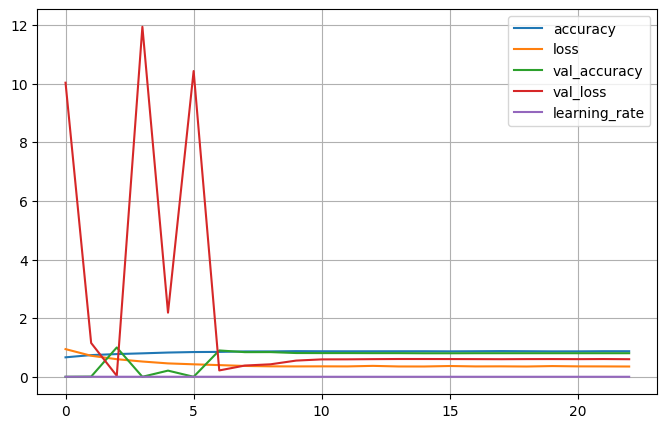

In [35]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [36]:
predictions = model.predict(validation_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 275ms/step


In [38]:
print(validation_generator.class_indices)
print(validation_generator.classes[:20])
print(predictions.shape)

{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
(500, 4)


In [40]:
model.save('my_model.keras')

In [2]:
!pip install fastapi uvicorn python-multipart nest-asyncio pyngrok

In [10]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from fastapi import FastAPI, UploadFile, File
from PIL import Image
import numpy as np
import io
import threading
import uvicorn
import nest_asyncio

# Save the model in .h5 format for robust loading, then load it
model.save('my_model.h5')
model = load_model("my_model.h5")

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

print("Model loaded successfully ✅")

app = FastAPI()

@app.get("/")
def home():
    return {
        "status": "Brain Tumor Classification API is running"
    }

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    image = Image.open(
        io.BytesIO(contents)
    ).convert("RGB")
    image = image.resize((512, 512))
    image_array = np.array(
        image,
        dtype=np.float32
    ) / 255.0
    input_image = np.expand_dims(
        image_array,
        axis=0
    )
    pred = model.predict(
        input_image,
        verbose=0
    )
    predicted_index = int(np.argmax(pred[0]))
    predicted_class = class_names[predicted_index]
    confidence = float(np.max(pred[0]))
    probabilities = {
        class_names[i]: float(pred[0][i])
        for i in range(len(class_names))
    }
    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "probabilities": probabilities
    }

nest_asyncio.apply()

def run_server():
    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )

thread = threading.Thread(
    target=run_server,
    daemon=True
)
thread.start()
print("API started on port 8000 🚀")

Model loaded successfully ✅
API started on port 8000 🚀


INFO:     Started server process [1128]
INFO:     Waiting for application startup.


In [11]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [ ]:
import subprocess

process = subprocess.Popen(
    ["/content/cloudflared", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in process.stdout:
    print(line)

2026-08-20T04:44:55Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps

2026-08-20T04:44:55Z INF Requesting new quick Tunnel on trycloudflare.com...

2026-08-20T04:45:01Z INF +--------------------------------------------------------------------------------------------+

2026-08-20T04:45:01Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |

2026-08-20T04:45:01Z INF |  https://ran-prize-alcohol-advance.trycloudflare.c

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 96, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors